In [15]:
%load_ext autoreload
%autoreload 2

In [16]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import matplotlib
import seaborn as sns
import copy
import pickle
import warnings
warnings.filterwarnings('ignore')
import shap
from models import *
from utilities import *

In [17]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [18]:
##########################################################################################################

In [19]:
import tensorflow as tf
tf.compat.v1.disable_v2_behavior()

Instructions for updating:
non-resource variables are not supported in the long term


In [20]:
shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough 
shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough

In [21]:
################### data import ###############

In [22]:
data_dir = '../results/data/'
data_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_dy_filter.pkl')
ba_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_ba_filter.pkl')
data_copy['Id_encoded'], uniques = pd.factorize(data_copy['SCCRIP_ID'])
mapping_dict = {value: index for index, value in enumerate(uniques)}

In [23]:
ba_copy['Id_encoded'] = ba_copy['SCCRIP_ID'].map(mapping_dict)
ba_copy = ba_copy[ba_copy['Id_encoded'].notna()]
ba_copy = ba_copy.drop_duplicates(subset='SCCRIP_ID', keep='last')
ba_copy.drop('SCCRIP_ID', inplace=True, axis=1)

In [24]:
ba_copy = ba_copy.fillna(0)
data_copy = data_copy.fillna(0)

In [25]:
with open(data_dir +  'SCCRIP_ID_dict.pkl', 'wb') as f:
    pickle.dump(mapping_dict, f)

In [26]:
len(data_copy.SCCRIP_ID.unique())

1267

In [27]:
################ data process ##################

In [28]:
import pickle, gzip
from pathlib import Path

def save_y_and_params(y_dict, params, out_path, compress=True):
    """
    y_dict: e.g. {"train": y_train, "val": y_val, "test": y_test}
    params: dict of hyperparameters/config
    out_path: path to .pkl or .pkl.gz
    """
    payload = {"y": y_dict, "params": params}
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    opener = gzip.open if compress else open
    with opener(out_path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_y_and_params(path, compressed=True):
    opener = gzip.open if compressed else open
    with opener(path, "rb") as f:
        payload = pickle.load(f)
    return payload["y"], payload["params"]


In [29]:
ctxn_c = []
for c in data_copy.columns:
    if 'ctxn' in c.lower():
        ctxn_c.append(c)
data_copy.drop(ctxn_c, axis = 1, inplace=True)

In [30]:
ba_ctxn = []
for  c in ba_copy.columns:
    if 'ctxn' in c.lower():
        ba_ctxn.append(c)
ba_copy.drop(ba_ctxn, axis = 1, inplace=True)

In [31]:
ctxn = read_sas('../data/Apply_MI_Zheng_2023_01/ctxn.sas7bdat')
blood_trans = read_sas('../data/Apply_MI_Zheng_2023_01/bloodtrans_final.sas7bdat')

In [32]:
blood_trans = blood_trans[['SCCRIP_ID',	'BloodTran_Start_DT']]
ctxn = ctxn[['SCCRIP_ID',	'CTXN_Start_DT1']]

In [33]:
def remove_rows_within_n_days(data_copy: pd.DataFrame,
                             blood_trans: pd.DataFrame,
                             n: int) -> pd.DataFrame:
    # Make sure dates are datetime
    dc = data_copy.copy()
    dc['date'] = pd.to_datetime(dc['date'])
    bt = blood_trans.copy()
    bt['BloodTran_Start_DT'] = pd.to_datetime(bt['BloodTran_Start_DT'])

    # Keep original row index to identify rows later
    dc = dc.reset_index().rename(columns={'index': 'orig_idx'})

    # Merge to get all Start_DT for each SCCRIP_ID
    merged = dc.merge(bt[['SCCRIP_ID', 'BloodTran_Start_DT']], on='SCCRIP_ID', how='left')

    # Condition: Start_DT < date <= Start_DT + n days
    mask = (
        merged['BloodTran_Start_DT'].notna()
        & (merged['date'] > merged['BloodTran_Start_DT'])
        & (merged['date'] <= merged['BloodTran_Start_DT'] + pd.Timedelta(days=n))
    )

    # Find original rows that match the condition for ANY Start_DT
    bad_idx = merged.loc[mask, 'orig_idx'].unique()

    # Drop those rows from the original data_copy
    result = dc[~dc['orig_idx'].isin(bad_idx)].drop(columns='orig_idx')

    return result

def add_ctxn_flag(data_copy: pd.DataFrame,
                  ctxn: pd.DataFrame) -> pd.DataFrame:
    """
    Add a new column 'ctxn' to data_copy:
      ctxn = 1 if SCCRIP_ID in ctxn and date > CTXN_Start_DT1 (for that ID)
      ctxn = 0 otherwise.

    Assumes:
        - data_copy has ['SCCRIP_ID', 'date']
        - ctxn has ['SCCRIP_ID', 'CTXN_Start_DT1']
    """
    dc = data_copy.copy()
    cx = ctxn.copy()

    # Ensure datetime columns
    dc['date'] = pd.to_datetime(dc['date'])
    cx['CTXN_Start_DT1'] = pd.to_datetime(cx['CTXN_Start_DT1'])

    # Merge by SCCRIP_ID to attach CTXN_Start_DT1 to each data_copy row (if ID exists)
    merged = dc.merge(cx[['SCCRIP_ID', 'CTXN_Start_DT1']],
                      on='SCCRIP_ID', how='left')

    # Vectorized condition
    merged['ctxn'] = (
        (merged['CTXN_Start_DT1'].notna())
        & (merged['date'] > merged['CTXN_Start_DT1'])
    ).astype(int)

    # Drop the CTXN_Start_DT1 column if you don’t need it in the result
    merged = merged.drop(columns=['CTXN_Start_DT1'])

    return merged

from sklearn.metrics import r2_score
from scipy.stats import pearsonr
def regression_metrics(y_true, y_pred, nrmse_mode="range"):
    """
    Compute MAE, RMSE, NRMSE, Pearson r, calibration slope, and R².

    Args:
        y_true: array-like, shape (N,)
        y_pred: array-like, shape (N,)
        nrmse_mode: 
            "range" -> NRMSE = RMSE / (max(y_true) - min(y_true))
            "mean"  -> NRMSE = RMSE / mean(y_true)

    Returns:
        dict with keys:
        ['MAE', 'RMSE', 'NRMSE', 'Pearson_r', 'Calibration_slope', 'R2']
    """
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)

    # Basic errors
    diff = y_pred - y_true
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff ** 2))

    # NRMSE
    if nrmse_mode == "range":
        denom = np.max(y_true) - np.min(y_true)
    elif nrmse_mode == "mean":
        denom = np.mean(y_true)
    else:
        raise ValueError("nrmse_mode must be 'range' or 'mean'")
    nrmse = rmse / denom if denom != 0 else np.nan

    # Pearson correlation
    pearson_r, _ = pearsonr(y_true, y_pred)

    # Calibration slope: fit y_true = a + b * y_pred
    # b is the calibration slope
    slope, intercept = np.polyfit(y_pred, y_true, 1)

    # R²
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "NRMSE": nrmse,
        "Pearson_r": pearson_r,
        "Calibration_slope": slope,
        "R2": r2,
    }

In [48]:
from scipy.stats import mannwhitneyu
import math


def plot_performance_boxplots(performance,n, tick_fontsize=16, label_fontsize=20,
                              grid_alpha=0.3, frame_color='black', frame_width=1.2, figure_dir = "../results/figures/mix/"):
    """
    Plot boxplots for ctxn vs non-ctxn performance metrics
    arranged in a (2, n_metrics/2) grid layout, with aligned
    p-value annotations, grids, and visible frames on each subplot.
    """
    metrics = list(performance['ctxn'].keys())

    # Flatten dict → DataFrame
    rows = []
    for group in ['ctxn', 'non-ctxn']:
        for metric in metrics:
            for v in performance[group][metric]:
                rows.append({'group': group, 'metric': metric, 'value': v})
    df = pd.DataFrame(rows)

    # Layout: 2 rows × ceil(n_metrics / 2) columns
    n_metrics = len(metrics)
    n_cols = math.ceil(n_metrics / 2)
    fig, axes = plt.subplots(2, n_cols, figsize=(5*n_cols, 10))
    axes = axes.flatten()

    y_pos_axes = 1.02  # p-value label height (in relative axis coordinates)

    for i, metric in enumerate(metrics):
        ax = axes[i]
        data_m = df[df['metric'] == metric]

        sns.boxplot(
            data=data_m,
            x='group', y='value',
            palette=['#1f77b4', '#ff7f0e'],
            ax=ax
        )

        
        ax.grid(True, axis='y', linestyle='--', alpha=grid_alpha)
        ax.set_axisbelow(True)

        
        # for spine in ax.spines.values():
        #     spine.set_visible(True)
        #     spine.set_color(frame_color)
        #     spine.set_linewidth(frame_width)

        # Mann–Whitney U test for p-value
        x = performance['ctxn'][metric]
        y = performance['non-ctxn'][metric]
        if len(x) > 1 and len(y) > 1:
            _, pval = mannwhitneyu(x, y, alternative='two-sided')
        else:
            pval = np.nan

        # Significance label
        if np.isnan(pval):
            label = "n/a"
        elif pval < 0.00001:
            label = '*****'
        elif pval < 0.0001:
            label = '****'
        elif pval < 0.001:
            label = "***"
        elif pval < 0.01:
            label = "**"
        elif pval < 0.05:
            label = "*"
        else:
            label = "ns"

        y_min, y_max = ax.get_ylim()
        y_star = y_max - 0 * (y_max - y_min)
        
        ax.text(
            0.5, y_star, label,
            ha='center', va='top',
            fontsize=label_fontsize,
            fontweight='bold'
        )
        ax.margins(y=0.15)
        # Titles, labels, ticks
        # ax.set_title(label, fontsize=label_fontsize)
        ax.set_xlabel(metric, fontsize=label_fontsize)
        ax.set_ylabel("", fontsize=label_fontsize)
        ax.tick_params(axis='x', labelsize=tick_fontsize)
        ax.tick_params(axis='y', labelsize=tick_fontsize)

    # Hide empty subplots (if odd number of metrics)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    f = figure_dir + 'ctxn_compare_n_' +str(n) + '.pdf'
    plt.savefig(f)
    plt.show()

In [27]:
n_list = [42, 60, 90]
figure_dir = "../results/figures/mix/"
seq_length = 5
paras_dict = {}
for n in n_list:
    data_filter = remove_rows_within_n_days(data_copy, blood_trans, n = n)
    print(n, len(data_filter))
    data_flag = add_ctxn_flag(data_filter, ctxn)
    performance = {'ctxn':{'R-square':[],
                           'MAE':[],
                           'RMSE':[],
                           'NRMSE':[],
                           'Pearson r':[],
                           'Calibration Slope':[]
                          },
                  'non-ctxn':{'R-square':[],
                           'MAE':[],
                           'RMSE':[],
                           'NRMSE':[],
                           'Pearson r':[],
                           'Calibration Slope':[]
                          }}
    r=0
    while r < 20:
        print(n, r)
        sequences, seq_ba, labels, date,  y_target = create_dataset(data_flag, ba_copy, seq_length, mapping_dict, addLabel='ctxn')
        sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
        X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
        X_normalized, X_bg_normalized = normalize_X(X, X_bg)

        (X_train,X_val,X_test,
                X_bg_train,X_bg_val,X_bg_test,
                dt_train, dt_val, dt_test, 
                y_train,y_val,y_test,
                ls_train, ls_val, ls_test,
                seq_map_train, seq_map_val, seq_map_test) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)

        combined_model = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train.shape[2]), bg_features=int(X_bg_train.shape[2]), summary=False)
        # Train the model
        history = combined_model.train(
            X_train, X_bg_train, dt_train, y_train,
            X_val,   X_bg_val,   dt_val,   y_val,
            epochs=20, batch_size=64,
            checkpoint_path="../results/models/mix_t.h5",
            verbose=0
        )

        y_pred = combined_model.predict(X_test, X_bg_test, dt_test)
        r2 = r2_score(y_test.flatten(), y_pred.flatten())
        if r2 > 0:
            last_col = ls_test[:, -1]          # get last column (0 or 1)
            y_pred = y_pred.flatten()
            y_test = y_test.flatten()

            pred_1 = y_pred[last_col == 1]
            pred_0 = y_pred[last_col == 0]

            test_1 = y_test[last_col == 1]
            test_0 = y_test[last_col == 0]

            m_1 = regression_metrics(pred_1, test_1)
            m_0 = regression_metrics(pred_0, test_0)
            performance['ctxn']['R-square'].append(m_1["R2"])
            performance['ctxn']['Pearson r'].append(m_1["Pearson_r"])
            performance['ctxn']['MAE'].append(m_1["MAE"])
            performance['ctxn']['RMSE'].append(m_1["RMSE"])
            performance['ctxn']['NRMSE'].append(m_1["NRMSE"])
            performance['ctxn']['Calibration Slope'].append(m_1["Calibration_slope"])

            performance['non-ctxn']['R-square'].append(m_0["R2"])
            performance['non-ctxn']['Pearson r'].append(m_0["Pearson_r"])
            performance['non-ctxn']['MAE'].append(m_0["MAE"])
            performance['non-ctxn']['RMSE'].append(m_0["RMSE"])
            performance['non-ctxn']['NRMSE'].append(m_0["NRMSE"])
            performance['non-ctxn']['Calibration Slope'].append(m_0["Calibration_slope"])
            r += 1
    plot_performance_boxplots(performance, n=n)
    paras_dict[n] = copy.deepcopy(performance)

42 22959
60 22412
90 21826


In [23]:
# with open("../results/data/mix/ctxn_compare.pkl", "wb") as f:
#         pickle.dump(paras_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

In [35]:
with open("../results/data/mix/ctxn_compare.pkl", "rb") as f:
        paras_dict = pickle.load(f)

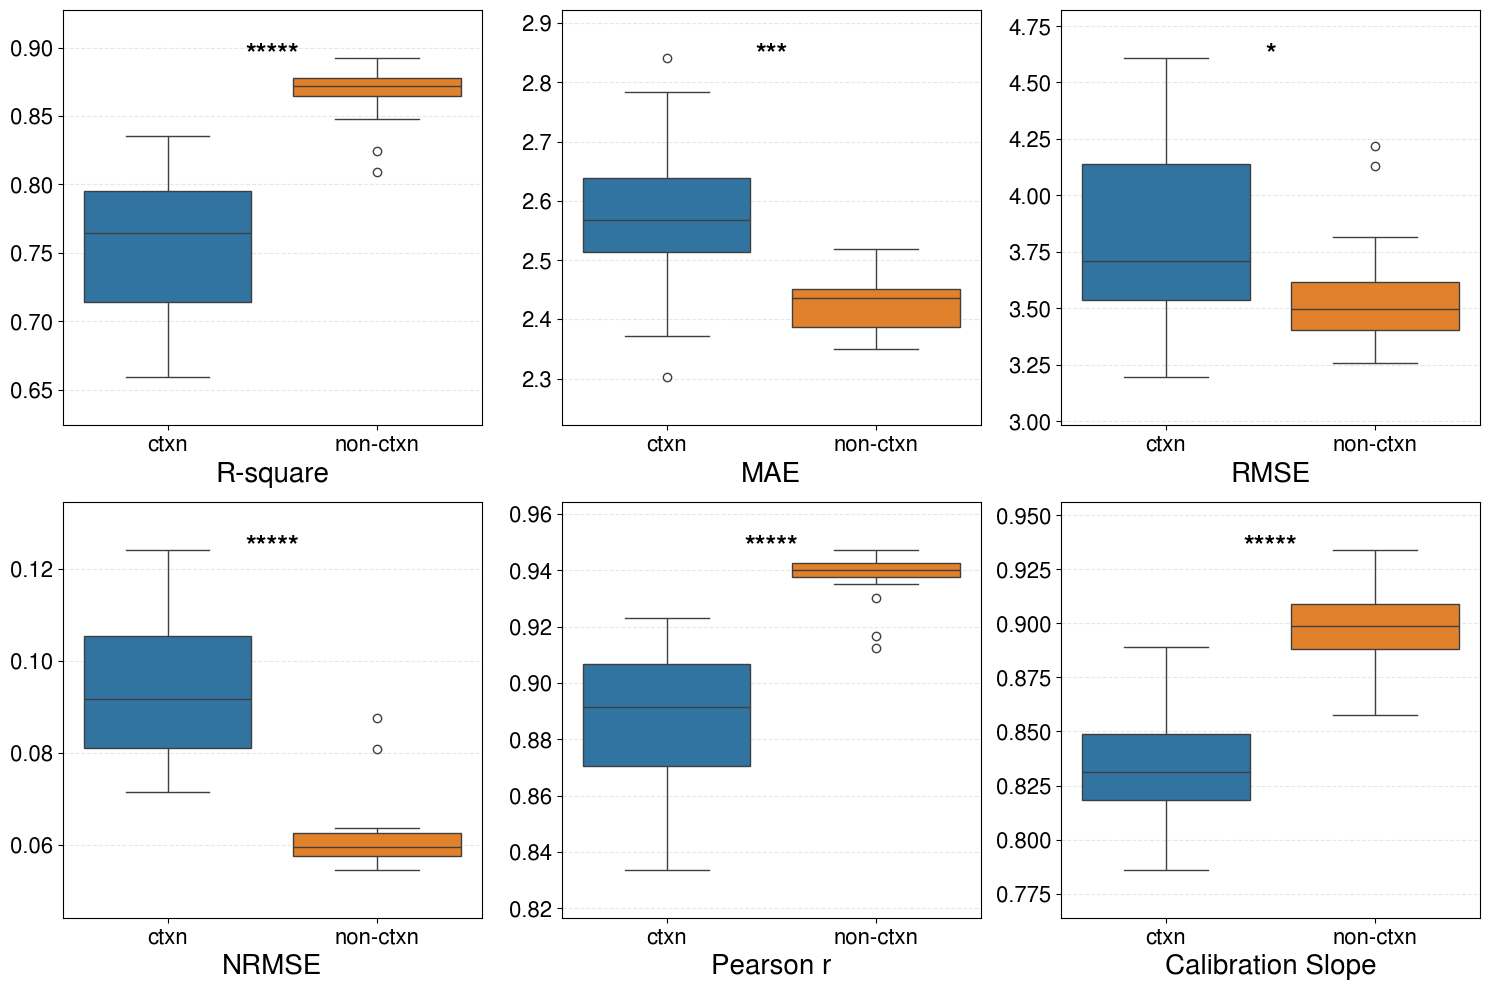

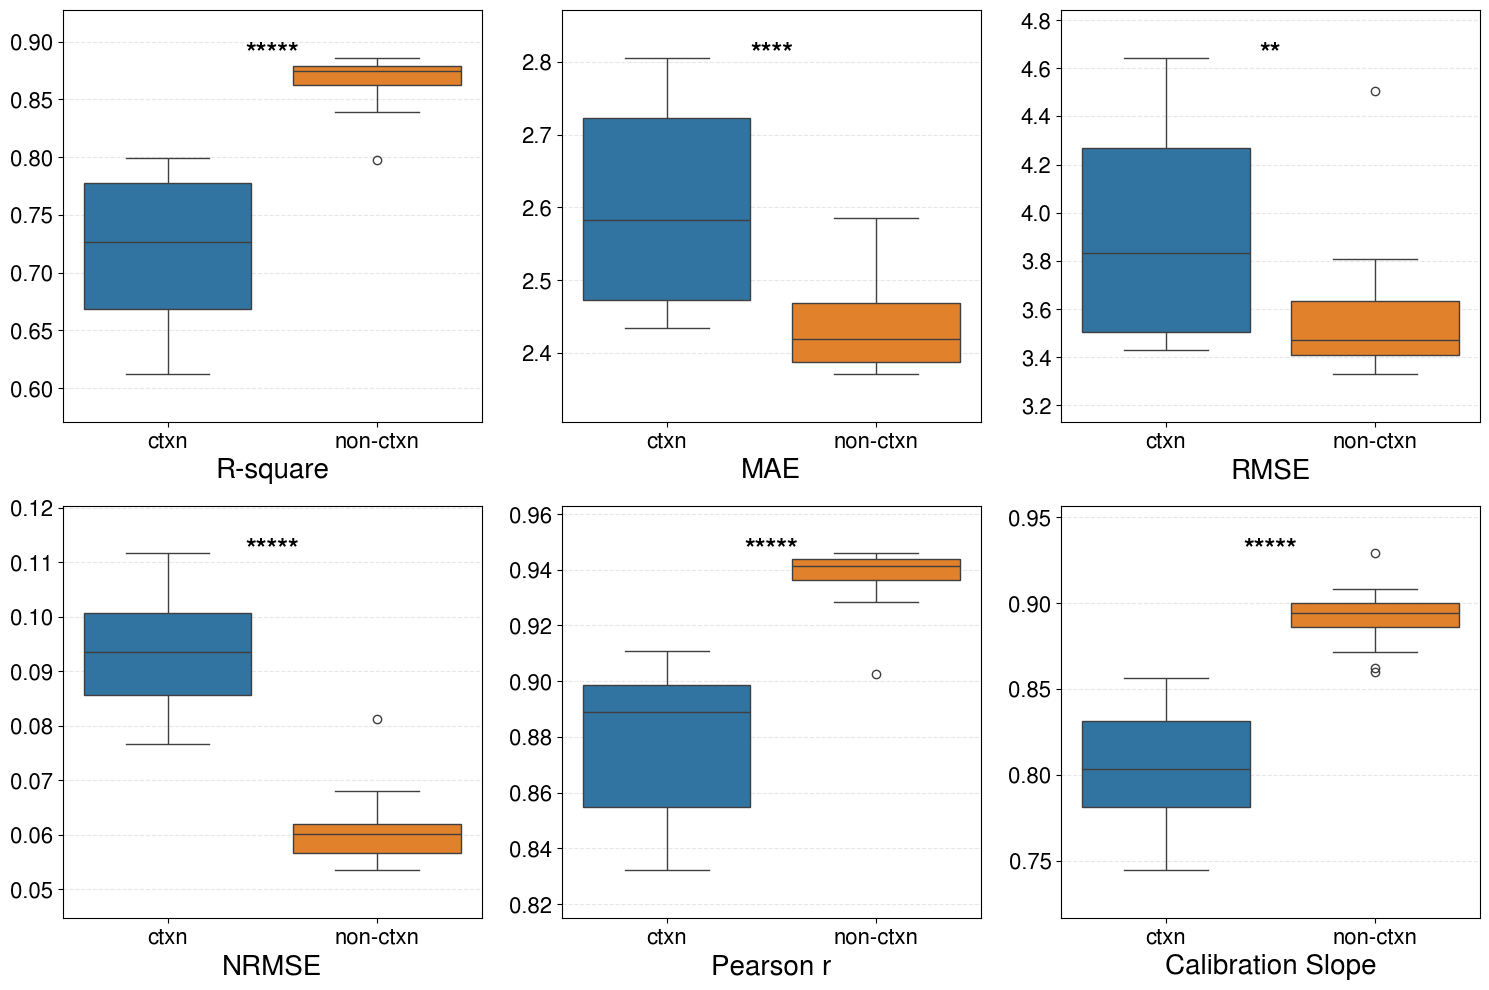

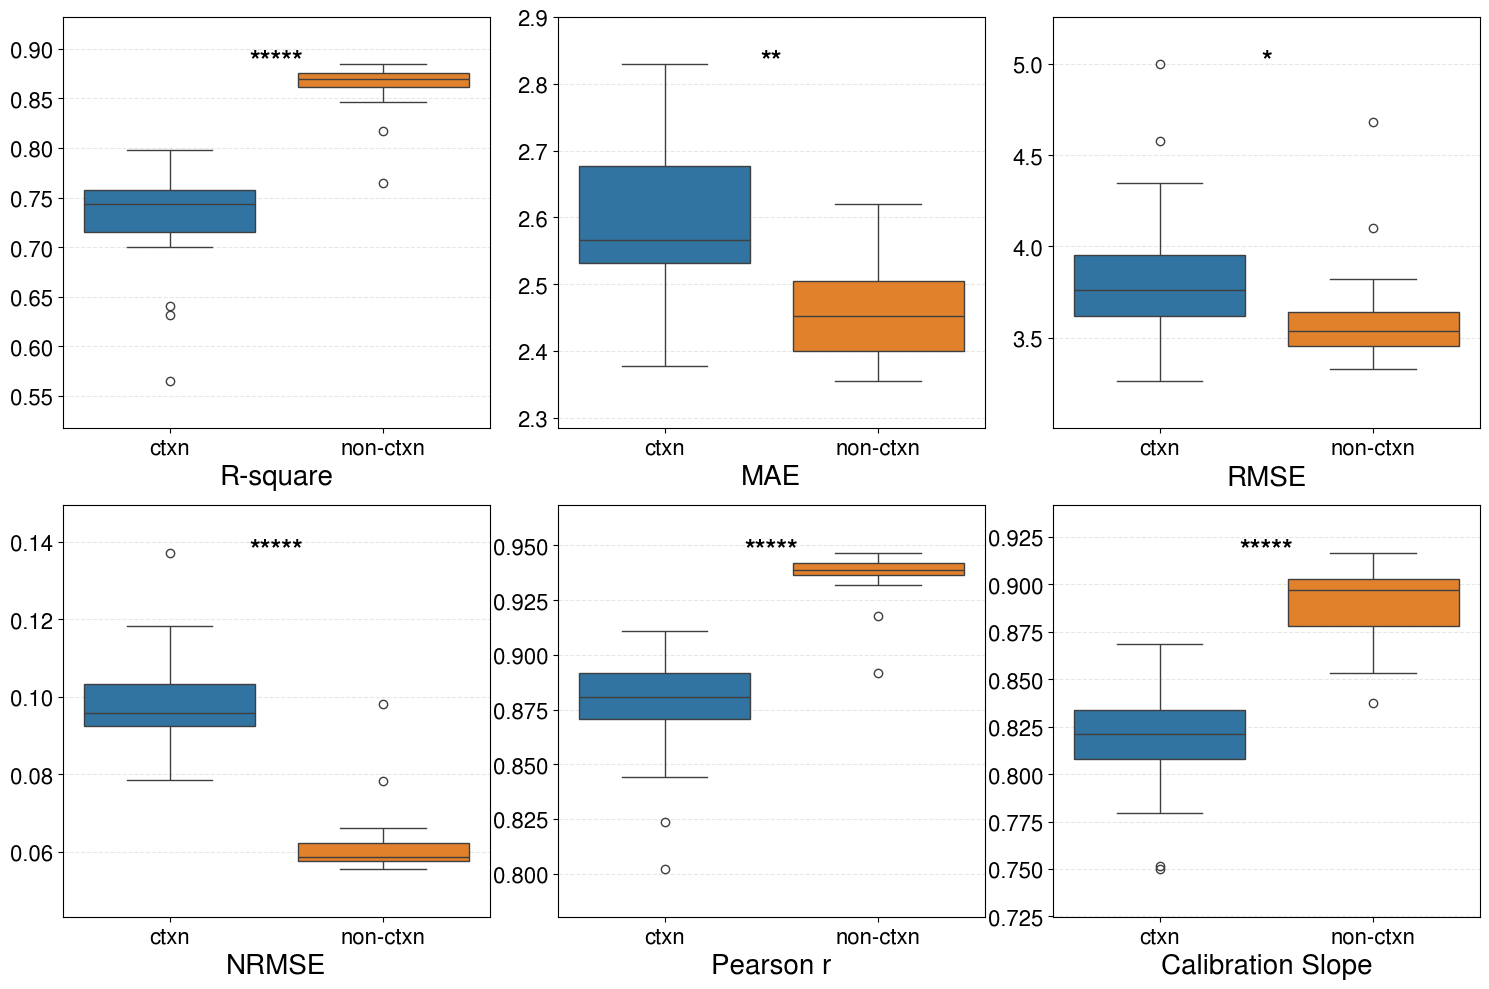

In [49]:
n_list = [42, 60, 90]
for n in n_list:
    performance = paras_dict[n]
    plot_performance_boxplots(performance, n=n)
